# Baseline Vision Transformer test

Tento notebook slúži ako prvý test vývojového prostredia pre diplomovú prácu.
Použitý je predtrénovaný Vision Transformer `vit_b_16` z knižnice torchvision.
Cieľom je overiť načítanie modelu, predspracovanie vstupného obrázka a získanie výstupných pravdepodobností tried.

Tento model zatiaľ predstavuje iba baseline riešenie. V ďalšej práci bude klasická klasifikačná hlava porovnávaná s prístupmi založenými na vynorení a viacvektorovej reprezentácii kategórií.

In [1]:
import torch
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models
from torchvision.models import ViT_B_16_Weights

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
weights = ViT_B_16_Weights.DEFAULT

model = models.vit_b_16(weights=weights)
model = model.to(device)
model.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

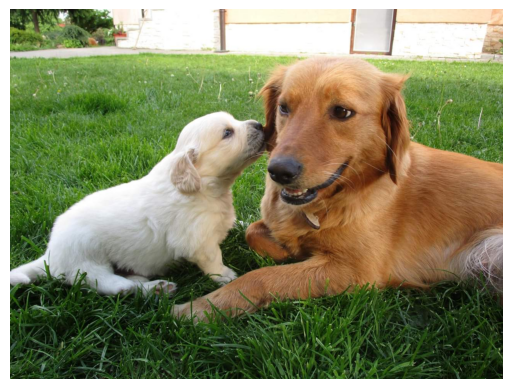

In [4]:
image_path = "../data/sample.jpeg"

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [5]:
preprocess = weights.transforms()

input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0).to(device)

input_batch.shape

torch.Size([1, 3, 224, 224])

In [6]:
with torch.no_grad():
    output = model(input_batch)

probabilities = torch.nn.functional.softmax(output[0], dim=0)

In [7]:
categories = weights.meta["categories"]

top5_prob, top5_catid = torch.topk(probabilities, 5)

for i in range(top5_prob.size(0)):
    print(f"{categories[top5_catid[i]]}: {top5_prob[i].item():.4f}")

golden retriever: 0.8354
Labrador retriever: 0.0116
kuvasz: 0.0057
tennis ball: 0.0031
Great Pyrenees: 0.0019
